In [6]:
import pandas as pd
import numpy as np

class DataPreprocess:

    def __init__(self, file_path):
        # Read CSV file
        self.df = pd.read_csv(file_path)
        print("Dataset loaded successfully.")
        print("Shape:", self.df.shape)

    def handle_missing_values(self):
        # Fill numerical columns with median
        num_cols = self.df.select_dtypes(include=['int64', 'float64']).columns
        self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].median())

        # Fill categorical columns with mode
        cat_cols = self.df.select_dtypes(include=['object']).columns
        self.df[cat_cols] = self.df[cat_cols].fillna(self.df[cat_cols].mode().iloc[0])

        print("Missing values handled.")

    def encode_categorical(self):

        self.df['alcohol_intake'] = (
            self.df['alcohol_consumption']
            .str.lower()
            .map({'none': 0, 'occasionally': 1, 'regularly': 2})
        )

        self.df['smoking'] = (
            self.df['smoking_level']
            .str.lower()
            .map({'non-smoker': 0, 'light': 1, 'heavy': 2})
        )

        self.df['mental_health_spt'] = (
            self.df['mental_health_support']
            .str.lower()
            .map({'yes': 0, 'no': 1})
        )

        self.df['exercise'] = (
            self.df['exercise_type']
            .str.lower()
            .map({'none': 0, 'cardio': 1, 'strength': 2, 'mixed': 3})
        )

        self.df['sunlight'] = (
            self.df['sunlight_exposure']
            .str.lower()
            .map({'low': 0, 'high': 1, 'moderate': 2})
        )

        self.df['sleep quality'] = (
            self.df['sleep_quality']
            .str.lower()
            .map({'good': 1, 'poor': 0, 'excellent': 2, 'fair': 1})
        )

        print("Categorical encoding completed.")

    def create_disease_labels(self):

        # High Insulin Flag (Assuming fasting insulin)
        self.df['High_Insulin'] = np.where(
            self.df['insulin'] > 25, 1, 0
        )
        # Diabetes
        self.df['Diabetes'] = np.where(
            ((self.df['glucose'] >= 126) & (self.df['sugar_intake'] > 50)) |
              ((self.df['bmi'] >= 30) & (self.df['sugar_intake'] > 50)) |
              ( (self.df['High_Insulin'] == 1)),
            1, 0
        )

        # Hypertension
        self.df['Hypertension'] = np.where(
            (self.df['blood_pressure'] >= 140) & (self.df['age'] >= 35)|
            ((self.df['bmi'] >= 30) & (self.df['stress_level'] > 6) &
             (self.df['age'] >= 35)),
            1, 0
        )

        # Cardiovascular
        self.df['Cardiovascular'] = np.where(
            (self.df['cholesterol'] >= 240) |
            ((self.df['smoking'] == 2) &
            (self.df['Hypertension'] == 1) &
            (self.df['Diabetes'] == 1))  |
            ((self.df['stress_level'] > 6) &
            (self.df['smoking'] == 2) &
            (self.df['Hypertension'] == 1) &
             (self.df['heart_rate'] > 90))    ,
            1, 0
        )

        # Obesity Class
        def bmi_category(bmi):
            if bmi < 25:
                return 0
            elif bmi < 30:
                return 1
            else:
                return 2

        self.df['Obesity_Class'] = self.df['bmi'].apply(bmi_category)

        # Healthy
        self.df['Healthy'] = np.where(
            (self.df['Diabetes'] == 0) &
            (self.df['Hypertension'] == 0) &
            (self.df['Cardiovascular'] == 0) &
            (self.df['Obesity_Class'] < 2),
            1, 0
        )

        print("Disease labels created.")

    def get_processed_data(self):
        return self.df


# Execute the code and create a new Master file with proper data
processor = DataPreprocess("Master dataset.csv")


processor.encode_categorical()
processor.create_disease_labels()
processor.handle_missing_values()

df_processed = processor.get_processed_data()

df_processed.head()

df_processed = df_processed.drop(columns=["occupation", "insurance", "device_usage",
                      "bmi_estimated", "bmi_scaled", "bmi_corrected",
                      "waist_size", "sleep_quality", "work_hours",
                      "education_level", "job_type", "occupation", "diet_type",
                      "target", "electrolyte_level", "gene_marker_flag",
                      "environmental_risk_score", "daily_supplement_dosage"
                      ])

df_processed.to_csv("Master_dataset_with_labels.csv", index=False)
print("New dataset saved successfully.")



Dataset loaded successfully.
Shape: (100000, 48)
Categorical encoding completed.
Disease labels created.
Missing values handled.
New dataset saved successfully.


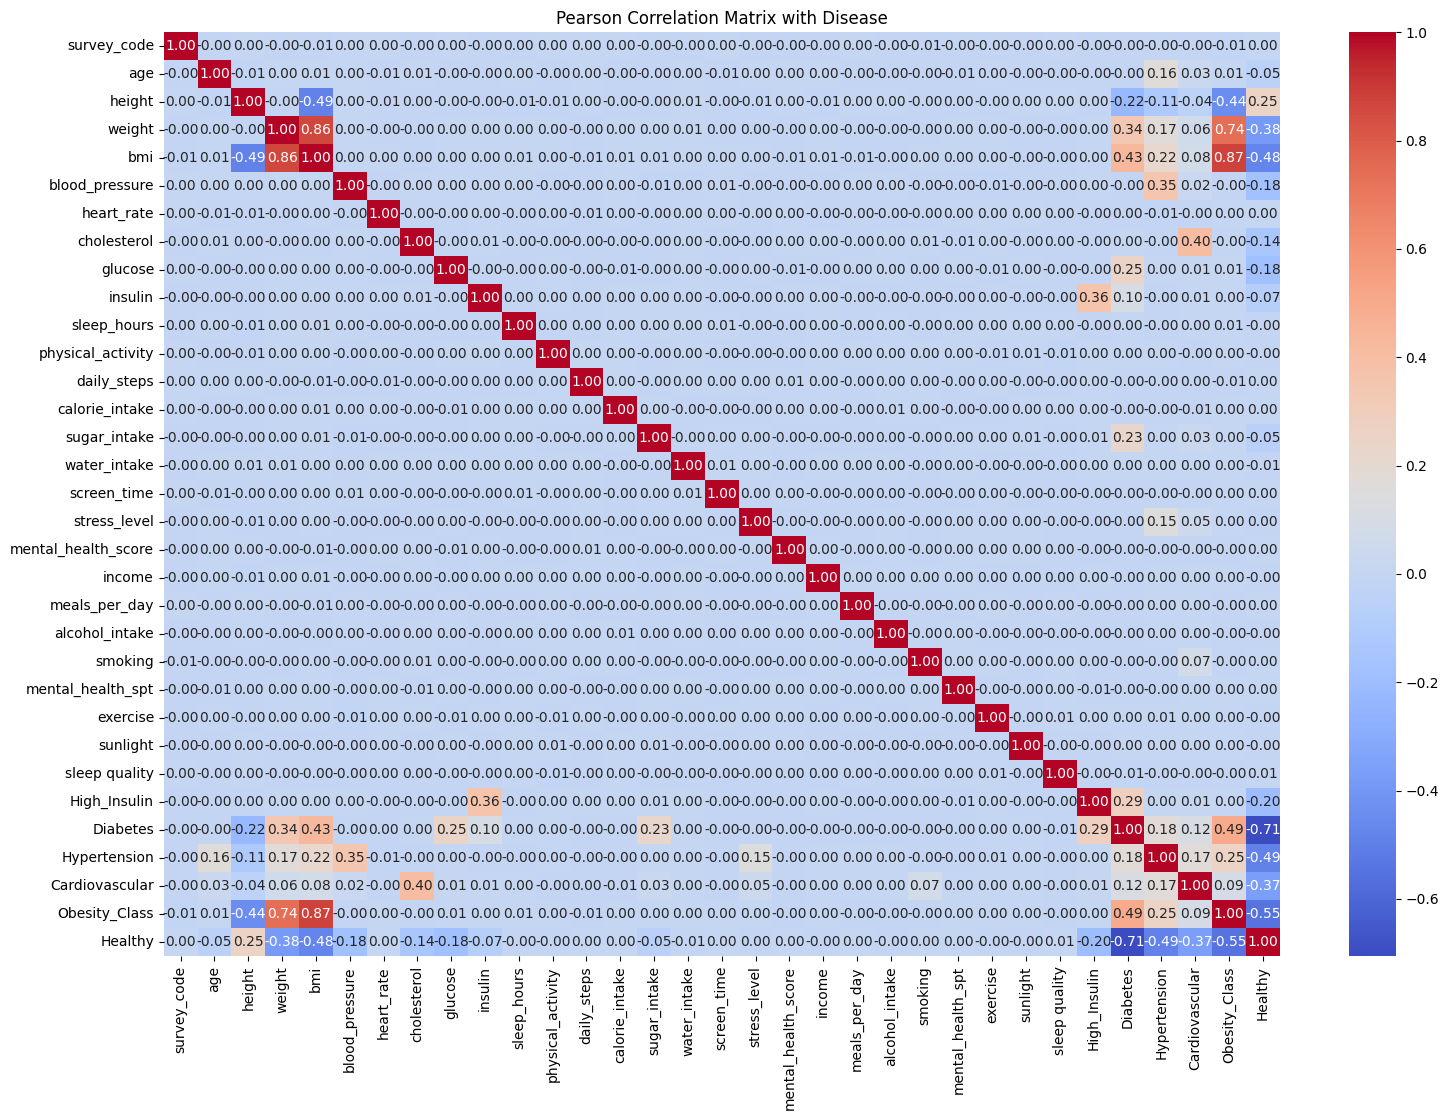

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Master_dataset_with_labels.csv")

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

# Compute Pearson correlation
corr_matrix = numeric_df.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Pearson Correlation Matrix with Disease")
plt.show()

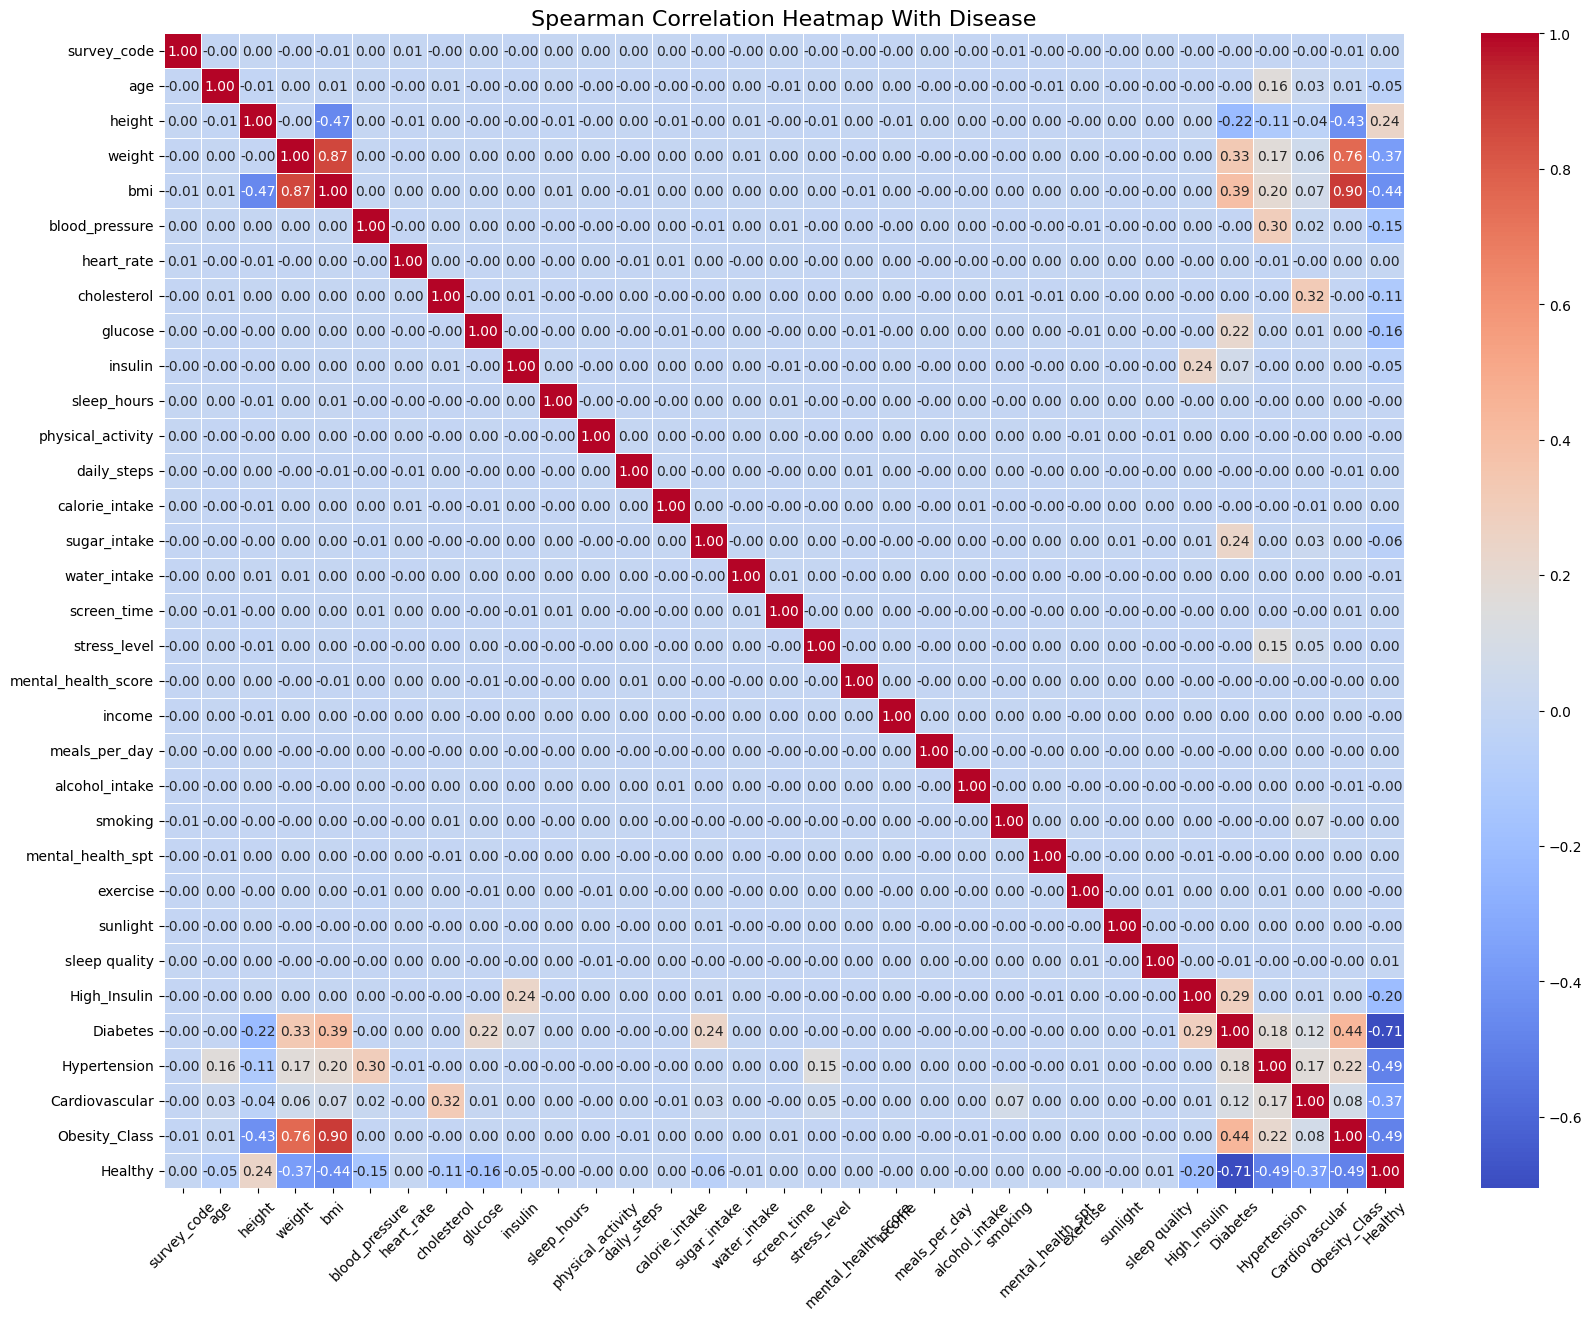

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Master_dataset_with_labels.csv")

# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate Spearman correlation
spearman_corr = numeric_df.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(20,15))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap With Disease", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()